# 📊 Visualization assignment
**Curso:** Programacion I  

---

**Graphs included:**
1. Line Plot - Promedio de temperatura
2. Bar Chart - Popularidad de lenguages de programacion
3. Histogram - Distribucion de notas de dos grupos de estudiantes
4. Scatter Plot - Horas de estudio dedicadas VS nota de examen
5. Custom Dashboard - Mapa de calor de episodios de una serie de television 

In [50]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

---
## 1. 📈 Line Plot - Promedio de temperatura

Este gráfico de líneas muestra la temperatura mensual promedio en tres ciudades — Buenos Aires, Londres y Tokio — a lo largo de 2024. Cada ciudad usa un color, forma de marcador y estilo de línea distintos para facilitar la comparación, con áreas sombreadas que enfatizan el rango de temperatura. Un gráfico de líneas es ideal aquí porque la temperatura es una variable continua en el tiempo, y conectar los puntos revela tendencias y ciclos estacionales.

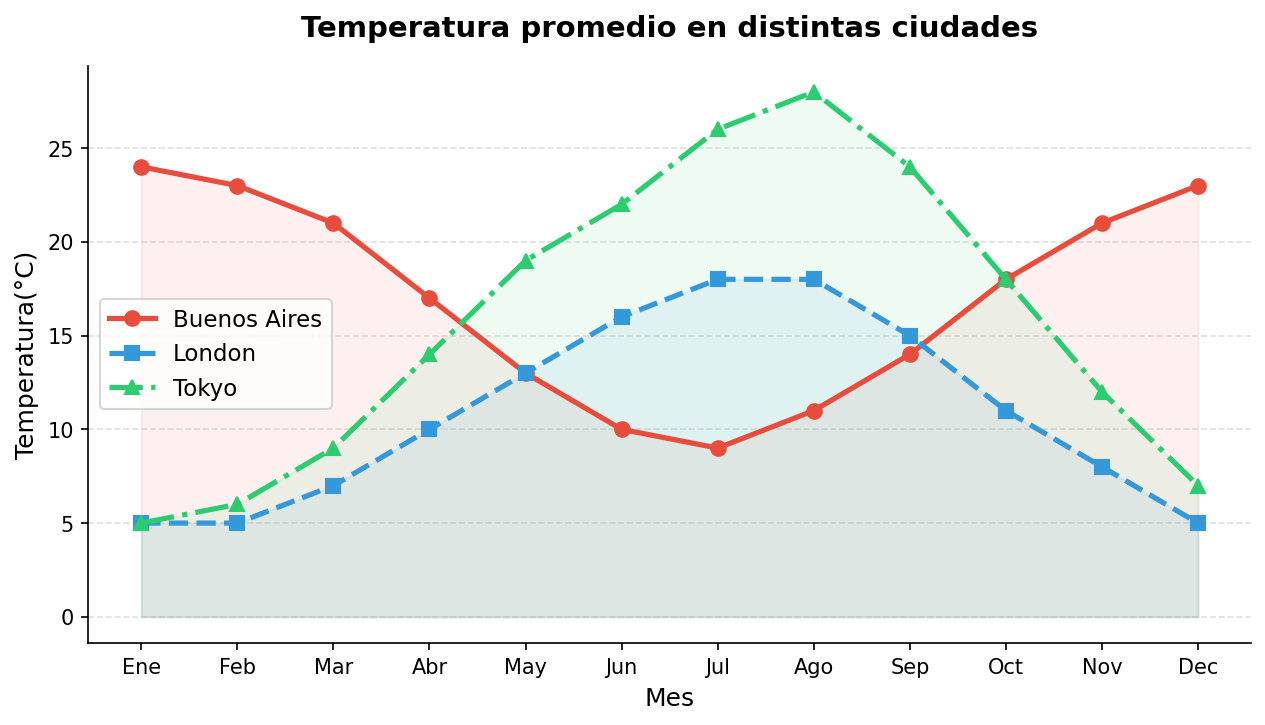

In [51]:
np.random.seed(42)

months = np.arange(1, 13)
month_names = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
               'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dec']

# Monthly average temperatures (°C) — approximate real-world data
bsas   = np.array([24, 23, 21, 17, 13, 10,  9, 11, 14, 18, 21, 23])
london = np.array([ 5,  5,  7, 10, 13, 16, 18, 18, 15, 11,  8,  5])
tokyo  = np.array([ 5,  6,  9, 14, 19, 22, 26, 28, 24, 18, 12,  7])

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(months, bsas,   color='#E74C3C', marker='o', linewidth=2.5,
        markersize=7, linestyle='-',  label='Buenos Aires')
ax.plot(months, london, color='#3498DB', marker='s', linewidth=2.5,
        markersize=7, linestyle='--', label='London')
ax.plot(months, tokyo,  color='#2ECC71', marker='^', linewidth=2.5,
        markersize=7, linestyle='-.',  label='Tokyo')

# Shaded areas under each line
ax.fill_between(months, bsas,   alpha=0.08, color='#E74C3C')
ax.fill_between(months, london, alpha=0.08, color='#3498DB')
ax.fill_between(months, tokyo,  alpha=0.08, color='#2ECC71')

ax.set_xticks(months)
ax.set_xticklabels(month_names)
ax.set_title('Temperatura promedio en distintas ciudades',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Mes', fontsize=12)
ax.set_ylabel('Temperatura(°C)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.savefig('imgs/line_plot.png', dpi=300, bbox_inches='tight')



---
## 2. 📊 Bar Chart - Popularidad de lenguages de programacion

Este gráfico de barras compara el porcentaje de desarrolladores que usan cada lenguaje de programación según la Encuesta a Desarrolladores de Stack Overflow 2024. Cada barra usa el color oficial del lenguaje y las etiquetas de porcentaje aparecen encima de cada barra para una lectura rápida. Un gráfico de barras es ideal para comparaciones categóricas — permite un ranking visual inmediato entre grupos discretos.

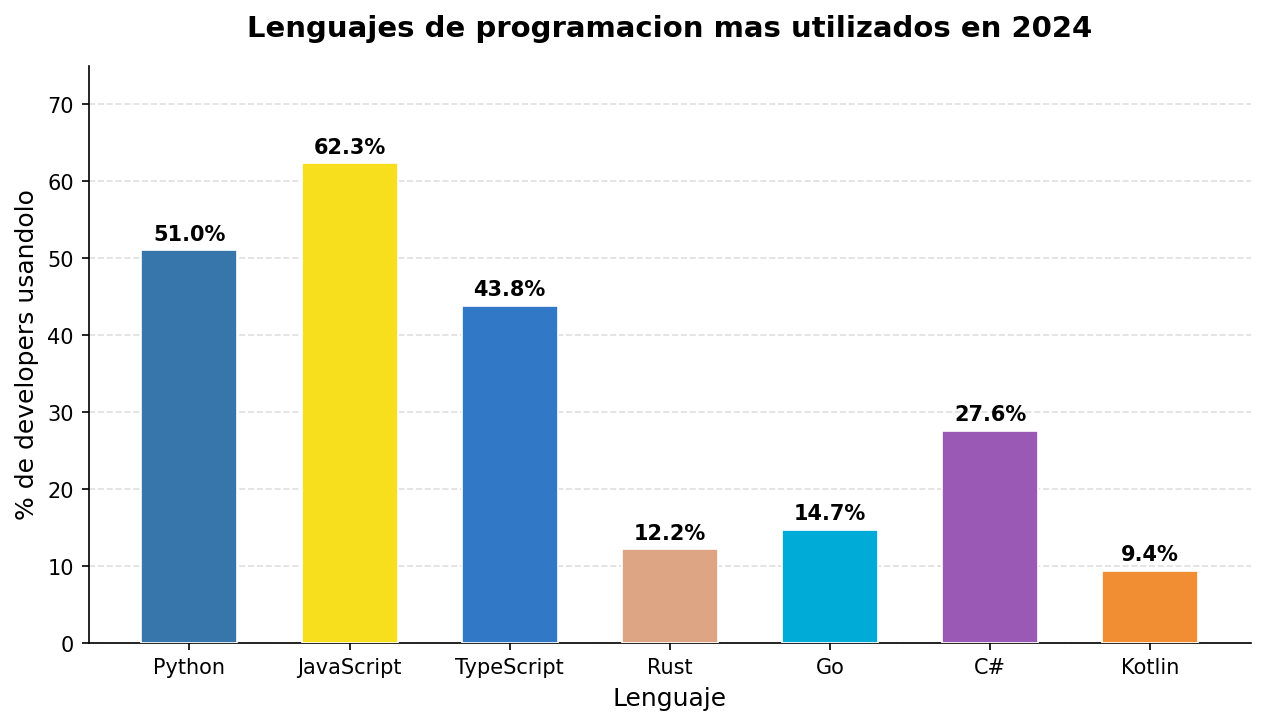

In [52]:
langs  = ['Python', 'JavaScript', 'TypeScript', 'Rust', 'Go', 'C#', 'Kotlin']
pct    = [51.0, 62.3, 43.8, 12.2, 14.7, 27.6, 9.4]
colors = ['#3776AB', '#F7DF1E', '#3178C6', '#DEA584', '#00ACD7', '#9B59B6', '#F18E33']

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(langs, pct, color=colors, edgecolor='white',
              linewidth=0.8, width=0.6, zorder=3)

for bar, val in zip(bars, pct):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'{val}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Lenguajes de programacion mas utilizados en 2024',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Lenguaje', fontsize=12)
ax.set_ylabel('% de developers usandolo', fontsize=12)
ax.set_ylim(0, 75)
ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
plt.savefig('imgs/bar_chart.png', dpi=300, bbox_inches='tight')




---
## 3. 📉 Histogram - Distribucion de notas

Este histograma muestra la distribución de notas del examen final para dos grupos de estudiantes (A y B), generados a partir de distribuciones normales con distintas medias. Las líneas verticales punteadas marcan el promedio de cada grupo. Las barras semitransparentes superpuestas facilitan la comparación. Un histograma es la herramienta estándar para visualizar la forma, dispersión y tendencia central de una distribución.

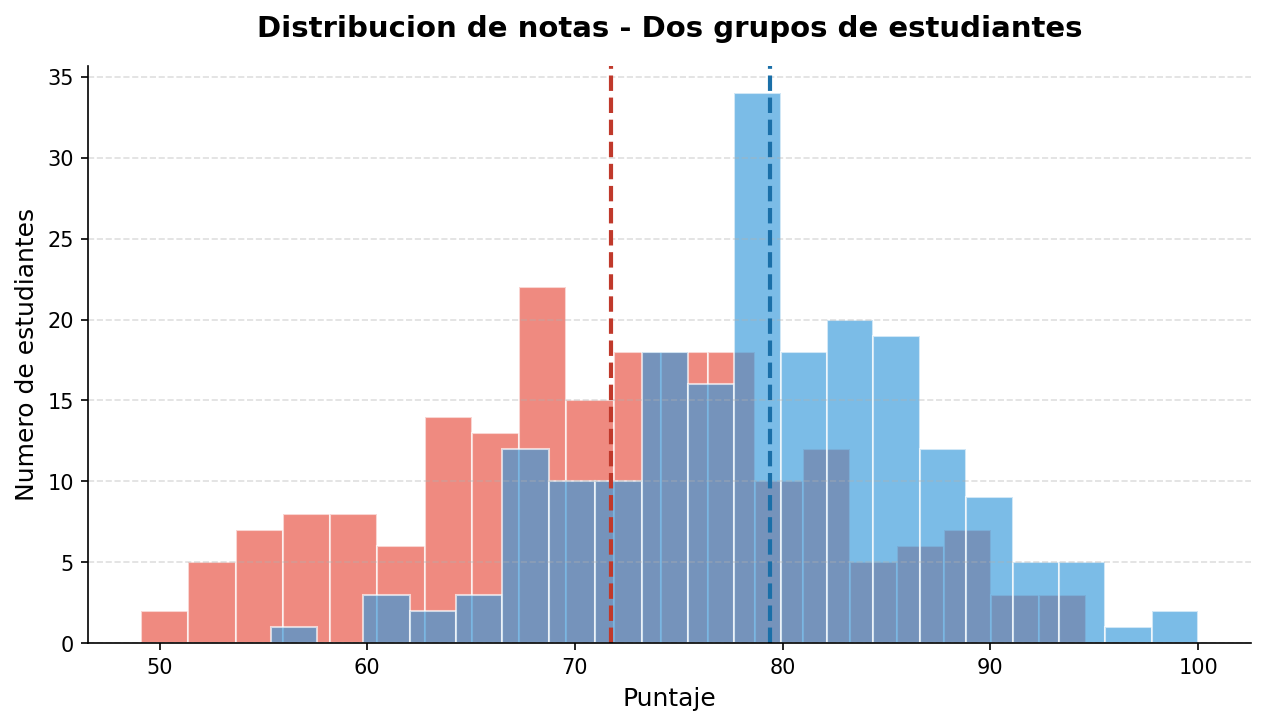

In [53]:
np.random.seed(7)

scores_a = np.random.normal(loc=72, scale=10, size=200).clip(0, 100)
scores_b = np.random.normal(loc=80, scale=8,  size=200).clip(0, 100)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(scores_a, bins=20, alpha=0.65, color='#E74C3C', edgecolor='white')
ax.hist(scores_b, bins=20, alpha=0.65, color='#3498DB', edgecolor='white')

ax.axvline(scores_a.mean(), color='#C0392B', linewidth=2, linestyle='--')
ax.axvline(scores_b.mean(), color='#1A6FA8', linewidth=2, linestyle='--')

ax.set_title('Distribucion de notas - Dos grupos de estudiantes',
             fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Puntaje', fontsize=12)
ax.set_ylabel('Numero de estudiantes', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.savefig('imgs/histogram.png', dpi=300, bbox_inches='tight')


---
## 4. 🔵 Scatter Plot - Nota de parcial VS tiempo de estudio

Este gráfico de dispersión muestra la relación entre las horas semanales de estudio y las notas del examen final para 120 estudiantes. Los puntos están coloreados según si aprobaron o no, una línea de regresión muestra la tendencia general, y una línea punteada marca el umbral de aprobación. Un gráfico de dispersión es ideal para investigar relaciones entre dos variables continuas y detectar valores atípicos.

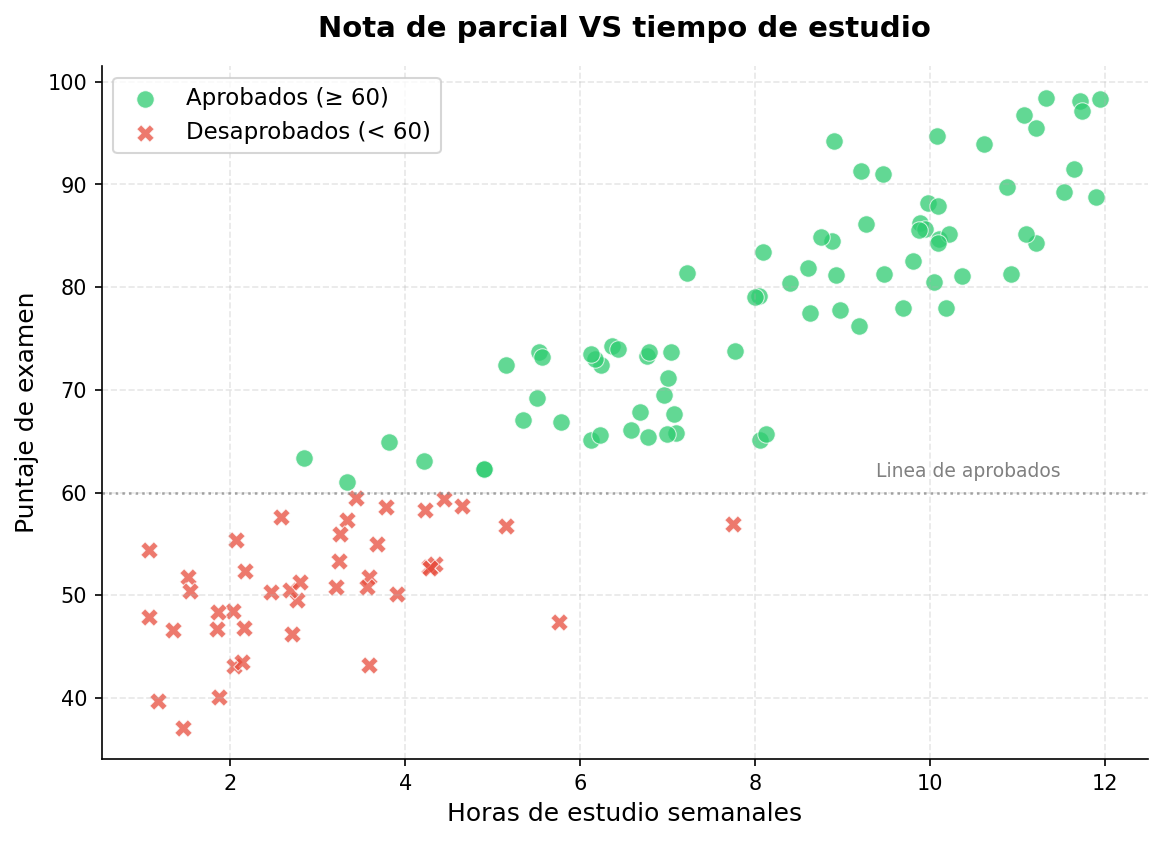

In [54]:
np.random.seed(99)

hours = np.random.uniform(1, 12, 120)
score = (40 + 4.5 * hours + np.random.normal(0, 6, 120)).clip(0, 100)
passed = score >= 60

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(hours[passed], score[passed],
           c='#2ECC71', alpha=0.75, edgecolors='white',
           linewidths=0.5, s=70, label='Aprobados (≥ 60)')

ax.scatter(hours[~passed], score[~passed],
           c='#E74C3C', alpha=0.75, edgecolors='white',
           linewidths=0.5, s=70, marker='X', label='Desaprobados (< 60)')

m, b = np.polyfit(hours, score, 1)
xfit = np.linspace(1, 12, 200)


ax.axhline(60, color='gray', linewidth=1.2, linestyle=':', alpha=0.7)
ax.text(11.5, 61.5, 'Linea de aprobados', ha='right', color='gray', fontsize=9)

ax.set_title('Nota de parcial VS tiempo de estudio', fontsize=14, fontweight='bold', pad=14)
ax.set_xlabel('Horas de estudio semanales', fontsize=12)
ax.set_ylabel('Puntaje de examen', fontsize=12)
ax.legend(fontsize=11)
ax.grid(linestyle='--', alpha=0.3)

plt.savefig('imgs/scatter_plot.png', dpi=300, bbox_inches='tight')


---
## 5. 🗂️ Custom Plot  - Mapa de calor

El gráfico 5 ahora es un mapa de calor con los puntajes reales de IMDb de los 62 episodios de Breaking Bad, organizado por temporada y episodio. Se puede ver claramente cómo la serie fue mejorando con el tiempo, con el pico máximo en Ozymandias (T5E14) y Face Off (T4E13), ambos con 9.9.

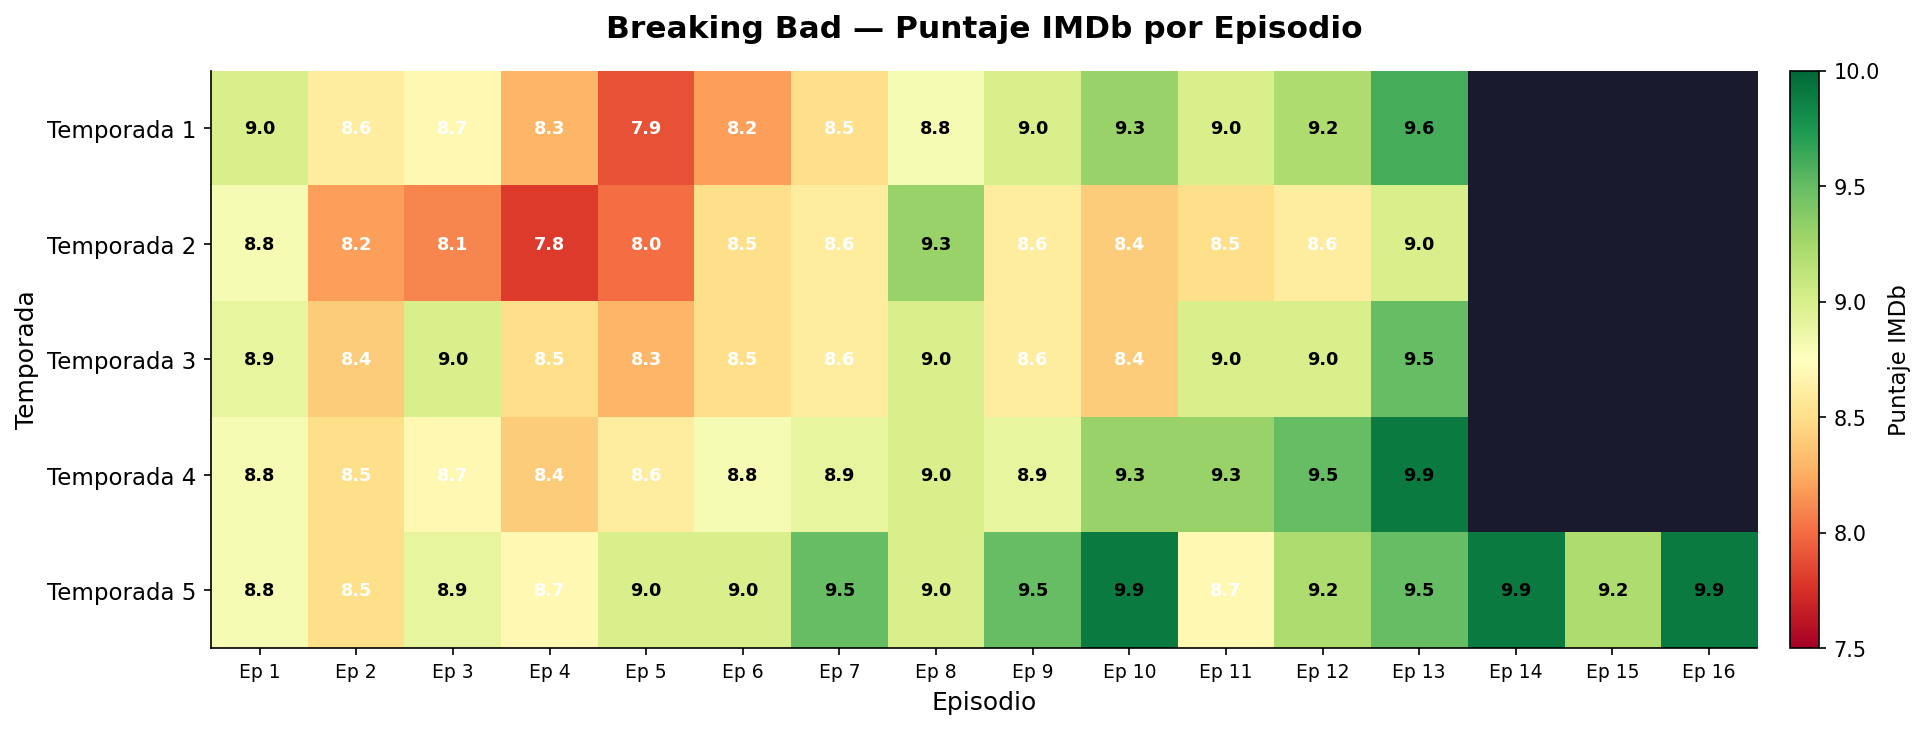

In [55]:
#%%
np.random.seed(21)

# Puntajes IMDb reales por episodio — Fuente: IMDb
ratings = {
    1: [9.0, 8.6, 8.7, 8.3, 7.9, 8.2, 8.5, 8.8, 9.0, 9.3, 9.0, 9.2, 9.6],
    2: [8.8, 8.2, 8.1, 7.8, 8.0, 8.5, 8.6, 9.3, 8.6, 8.4, 8.5, 8.6, 9.0],
    3: [8.9, 8.4, 9.0, 8.5, 8.3, 8.5, 8.6, 9.0, 8.6, 8.4, 9.0, 9.0, 9.5],
    4: [8.8, 8.5, 8.7, 8.4, 8.6, 8.8, 8.9, 9.0, 8.9, 9.3, 9.3, 9.5, 9.9],
    5: [8.8, 8.5, 8.9, 8.7, 9.0, 9.0, 9.5, 9.0, 9.5, 9.9, 8.7, 9.2, 9.5, 9.9, 9.2, 9.9],
}

max_eps = 16
seasons = [1, 2, 3, 4, 5]

# Construir matriz con NaN donde no hay episodio
matrix = np.full((5, max_eps), np.nan)
for i, s in enumerate(seasons):
    for j, r in enumerate(ratings[s]):
        matrix[i][j] = r

fig, ax = plt.subplots(figsize=(14, 5))

cmap = plt.colormaps['RdYlGn']
cmap.set_bad(color='#1a1a2e')  # Color para celdas vacías (NaN)

im = ax.imshow(matrix, cmap=cmap, vmin=7.5, vmax=10.0,
               aspect='auto', interpolation='nearest')

# Anotar cada celda con su puntaje
for i in range(5):
    for j in range(max_eps):
        val = matrix[i][j]
        if not np.isnan(val):
            color = 'white' if val < 8.8 else 'black'
            ax.text(j, i, f'{val:.1f}', ha='center', va='center',
                    fontsize=8.5, fontweight='bold', color=color)

ax.set_yticks(range(5))
ax.set_yticklabels([f'Temporada {s}' for s in seasons], fontsize=11)
ax.set_xticks(range(max_eps))
ax.set_xticklabels([f'Ep {j+1}' for j in range(max_eps)], fontsize=9)
ax.set_title('Breaking Bad — Puntaje IMDb por Episodio',
             fontsize=15, fontweight='bold', pad=16)
ax.set_xlabel('Episodio', fontsize=12)
ax.set_ylabel('Temporada', fontsize=12)

cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label('Puntaje IMDb', fontsize=11)

plt.savefig('imgs/custom_plot.png', dpi=300, bbox_inches='tight')
